In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [16]:
# Caminho onde as figuras serão salvas
save_dir = r"C:\Users\calva\OneDrive\Documentos\Doutorado\Proposta_de_Tese\Deep_Learning\artigo\MDPI_template_ACS\Definitions"
save_figures = True   # <<< coloque False se não quiser salvar

In [17]:
# -----------------------------------------
# Escolha o arquivo CSV
df = pd.read_csv("Second-Period.csv")
period = "Period_II"
# -----------------------------------------

In [18]:
COP = df["COP"].values

# Divisão usada no MLP (70/20/10)
X_train, X_temp = train_test_split(COP, test_size=0.30, random_state=42)
X_test, X_val   = train_test_split(X_temp, test_size=1/3, random_state=42)

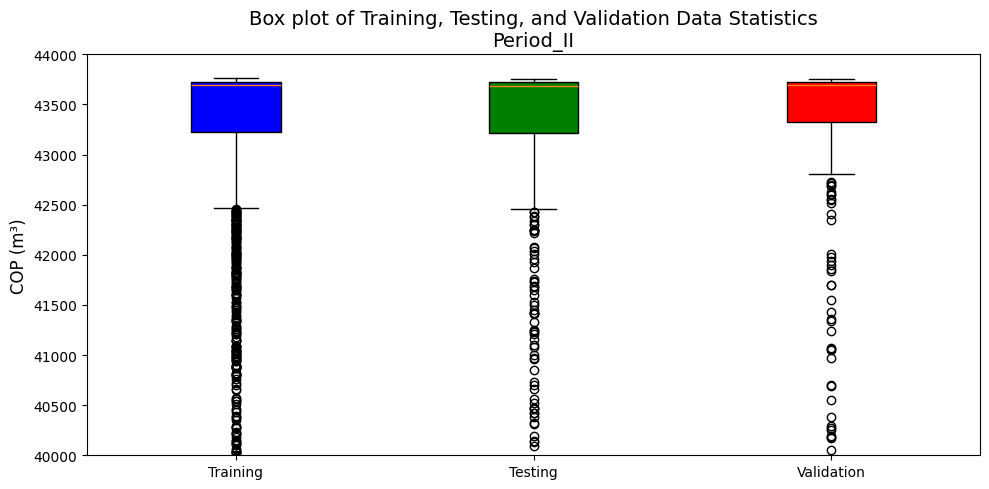

In [19]:
# =========================================
# BOX PLOT
# =========================================
plt.figure(figsize=(10,5))
bp = plt.boxplot(
    [X_train, X_test, X_val],
    patch_artist=True
)

colors = ["blue", "green", "red"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
plt.ylim(40000, 44000)
plt.xticks([1,2,3], ["Training", "Testing", "Validation"])
plt.ylabel("COP (m³)", fontsize=12)
plt.title(f"Box plot of Training, Testing, and Validation Data Statistics\n{period}", fontsize=14)

plt.tight_layout()
plt.show()   # <<< mostra no notebook

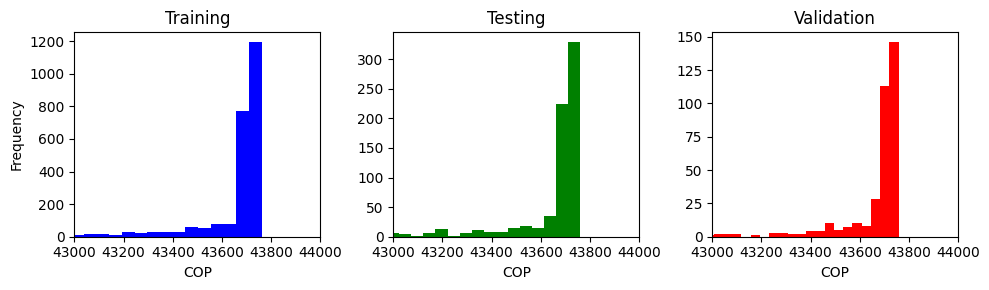

In [20]:
# HISTOGRAMAS
# =========================================
plt.figure(figsize=(10,3))

# Definir limites desejados
x_min, x_max = 43000, 44000   # ajuste conforme o período

plt.subplot(1,3,1)
plt.hist(X_train, bins=500, color="blue")
plt.title("Training")
plt.xlabel("COP")
plt.ylabel("Frequency")
plt.xlim(x_min, x_max)

plt.subplot(1,3,2)
plt.hist(X_test, bins=500, color="green")
plt.title("Testing")
plt.xlabel("COP")
plt.xlim(x_min, x_max)

plt.subplot(1,3,3)
plt.hist(X_val, bins=500, color="red")
plt.title("Validation")
plt.xlabel("COP")
plt.xlim(x_min, x_max)

plt.tight_layout()

plt.show()

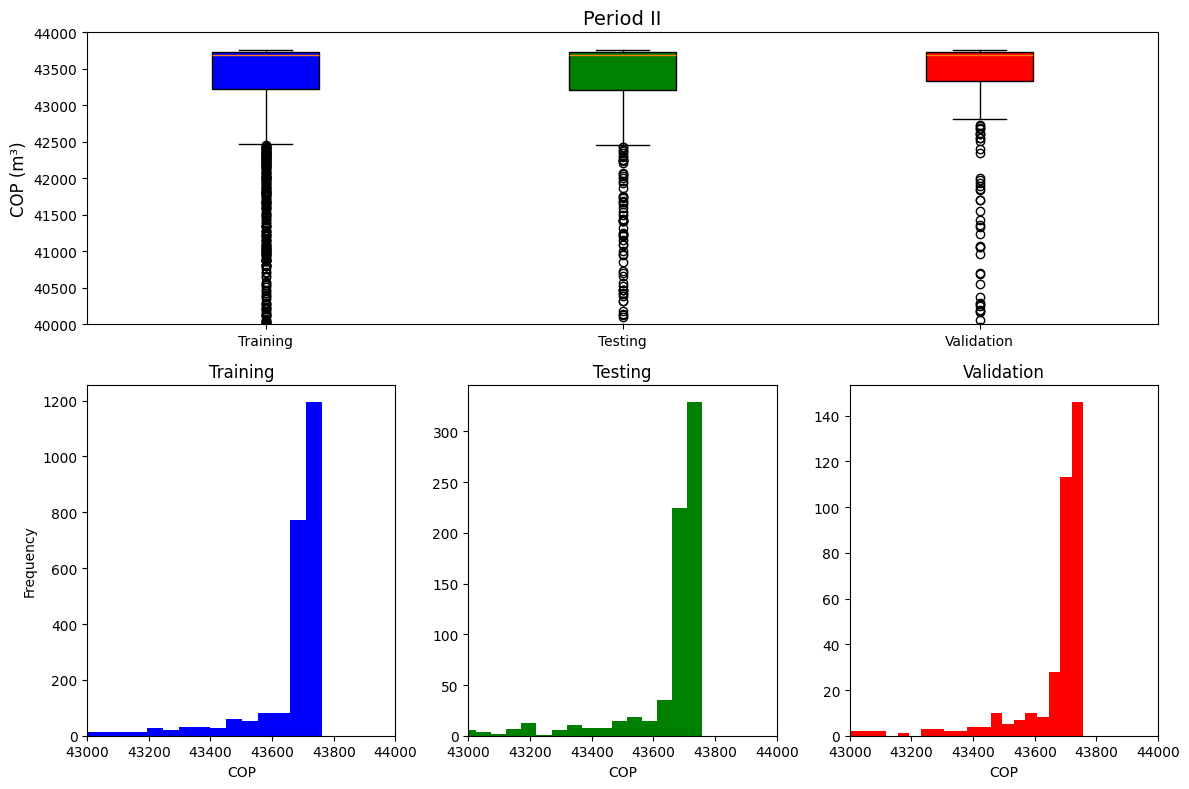

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# ============================
# FIGURA: BOXPLOT EM CIMA (100% largura)
#         3 HISTOGRAMAS EMBAIXO
# ============================

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.2])  # proporção visual

# ============================
# BOXPLOT (linha inteira)
# ============================

ax_box = fig.add_subplot(gs[0, :])   # ocupa TODAS as colunas da linha superior

bp = ax_box.boxplot(
    [X_train, X_test, X_val],
    patch_artist=True
)

colors = ["blue", "green", "red"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax_box.set_ylim(40000, 44000)
ax_box.set_xticks([1, 2, 3])
ax_box.set_xticklabels(["Training", "Testing", "Validation"])
ax_box.set_ylabel("COP (m³)", fontsize=12)
#ax_box.set_title(f"Box plot of Training, Testing, and Validation Data\n{period}", fontsize=14)
ax_box.set_title(f"Period II", fontsize=14)

# ============================
# HISTOGRAMAS (três colunas)
# ============================

x_min, x_max = 43000, 44000

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(X_train, bins=500, color="blue")
ax1.set_title("Training")
ax1.set_xlabel("COP")
ax1.set_ylabel("Frequency")
ax1.set_xlim(x_min, x_max)

ax2 = fig.add_subplot(gs[1, 1])
ax2.hist(X_test, bins=500, color="green")
ax2.set_title("Testing")
ax2.set_xlabel("COP")
ax2.set_xlim(x_min, x_max)

ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(X_val, bins=500, color="red")
ax3.set_title("Validation")
ax3.set_xlabel("COP")
ax3.set_xlim(x_min, x_max)

# ============================
# SALVAR FIGURA
# ============================

plt.tight_layout()

if save_figures:
    fig.savefig(f"{save_dir}/BoxHist_{period}.jpg", dpi=300)

plt.show()
